## Extraire le fichier Zip sur le SSD rapide

In [ ]:
import zipfile
import time
import os
import shutil
from google.colab import drive

# 1. On branche le Drive
drive.mount('/content/drive', force_remount=True)
zip_source = "/content/drive/MyDrive/UTBM_PF22/datasets/Animals-10/dataset_multifidelity.zip"
local_dest = "/content/processed_multifidelity"

# 2. On prépare les données sur le SSD local
if not os.path.exists(local_dest):
    print("⏳ Copie et extraction du Dataset sur le SSD...")
    start = time.time()
    shutil.copy2(zip_source, "/content/dataset.zip") 
    
    with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/") 
        
    os.remove("/content/dataset.zip") 
    print(f"✅ Données prêtes en {(time.time()-start):.2f} secondes !")
else:
    print("✅ Les données sont déjà prêtes sur le SSD local.")

Mounted at /content/drive
⏳ Copie et extraction du Dataset sur le SSD...
✅ Données prêtes en 21.18 secondes !


## Test des baselines avec 1 epoch

In [ ]:
import sys
import os
import importlib
import torch

print(f"🔥 Matériel : {'GPU PRO ACTIVÉ' if torch.cuda.is_available() else 'CPU (Erreur)'}")

src_path = "/content/drive/MyDrive/UTBM_PF22/src"

if not os.path.exists(src_path):
    print(f"❌ ERREUR : Le dossier {src_path} est introuvable sur le Drive.")
else:
    fichiers = os.listdir(src_path)
    if "train_baselines.py" not in fichiers:
        print(f"❌ ERREUR : 'train_baselines.py' n'est pas dans le dossier src !")
        print(f"💡 Fichiers trouvés : {fichiers}")
    else:
        # --- LA CORRECTION MAGIQUE EST ICI ---
        # 1. On force ton dossier en priorité NUMÉRO 1 absolue
        if src_path not in sys.path:
            sys.path.insert(0, src_path) 
        
        # 2. On ordonne à Python d'oublier ses anciens échecs d'importation
        importlib.invalidate_caches()

        # 3. Importation
        import train_baselines
        importlib.reload(train_baselines)
        from train_baselines import run_baseline

        try:
            print("\n🏁 DÉMARRAGE DU TEST D'INTÉGRATION (1 Époque)...")
            
            run_baseline(mode="HF", epochs=1)
            run_baseline(mode="BF", epochs=1)
            run_baseline(mode="MIXTE", epochs=1)
            
            print("\n🎉 LE TEST EST UN SUCCÈS ABSOLU ! TOUT FONCTIONNE !")
            
        except Exception as e:
            print(f"❌ ERREUR pendant l'entraînement : {e}")

🔥 Matériel : GPU PRO ACTIVÉ

🏁 DÉMARRAGE DU TEST D'INTÉGRATION (1 Époque)...

🚀 DÉMARRAGE BASELINE : HF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 2352
💰 Coût par époque : 23520 CA | Coût total estimé : 23520 CA
Époque 1/1 | Loss: 2.2092
⏱️ Entraînement terminé en 0.18 minutes.

--- RÉSULTATS D'ÉVALUATION ---
📊 Précision Test HF (Propre) : 21.50%
📊 Précision Test BF (Bruité) : 13.27%
📊 Précision Mixte (Moyenne) : 17.39%
💾 Résultats et Modèle sauvegardés dans /content/drive/MyDrive/UTBM_PF22/results

🚀 DÉMARRAGE BASELINE : BF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 21213
💰 Coût par époque : 21213 CA | Coût total estimé : 21213 CA
Époque 1/1 | Loss: 1.7878
⏱️ Entraînement terminé en 1.25 minutes.

--- RÉSULTATS D'ÉVALUATION ---
📊 Précision Test HF (Propre) : 43.61%
📊 Précision Test BF (Bruité) : 34.05%
📊 Précision Mixte (Moyenne) : 38.83%
💾 Résultats et Modèle sauvegardés dans /content/drive/MyDrive/UTBM_PF22/results

🚀 DÉMARRAGE BASELINE : MIXTE
🔥 

## Test des baselines avec 15 epoch

In [ ]:
import sys
import os
import importlib
import torch
import zipfile
import shutil
import time
from google.colab import drive

print("--- 🛠️ ÉTAPE 1 : RECONNEXION FORCÉE DU DRIVE ---")
# Cela va te redemander l'autorisation si la connexion était perdue
drive.mount('/content/drive', force_remount=True)

print("\n--- 📦 ÉTAPE 2 : VÉRIFICATION DES DONNÉES LOCALES ---")
zip_source = "/content/drive/MyDrive/UTBM_PF22/datasets/Animals-10/dataset_multifidelity.zip"
local_dest = "/content/processed_multifidelity"

if not os.path.exists(local_dest):
    print("⏳ Les données ont disparu du SSD (suite à la déconnexion). Re-décompression en cours...")
    start = time.time()
    shutil.copy2(zip_source, "/content/dataset.zip") 
    with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/") 
    os.remove("/content/dataset.zip") 
    print(f"✅ Données prêtes en {(time.time()-start):.2f} secondes !")
else:
    print("✅ Les données sont déjà prêtes sur le SSD local.")

print("\n--- 🚀 ÉTAPE 3 : LANCEMENT DE L'ENTRAÎNEMENT ---")
print(f"🔥 Matériel : {'GPU PRO ACTIVÉ' if torch.cuda.is_available() else 'CPU (LENT)'}")

src_path = "/content/drive/MyDrive/UTBM_PF22/src"

if not os.path.exists(src_path):
    print(f"❌ ERREUR : Le dossier {src_path} est introuvable.")
else:
    # 1. Priorité absolue au dossier
    if src_path not in sys.path:
        sys.path.insert(0, src_path) 
    
    # 2. Vider le cache des imports
    importlib.invalidate_caches()

    # 3. Importation
    import train_baselines
    importlib.reload(train_baselines)
    from train_baselines import run_baseline

    try:
        # --- PARAMÈTRE DE L'EXPÉRIENCE ---
        NB_EPOCHS = 20 
        
        print(f"\n🏁 DÉMARRAGE DE L'ENTRAÎNEMENT COMPLET ({NB_EPOCHS} Époques)...")
        print("⚠️ Cette opération prendra environ 45 à 60 minutes au total.")
        print("☕ Tu peux laisser cet onglet ouvert et faire autre chose !\n")
        
        # Lancement des 3 baselines à la suite
        run_baseline(mode="HF", epochs=NB_EPOCHS)
        run_baseline(mode="BF", epochs=NB_EPOCHS)
        run_baseline(mode="MIXTE", epochs=NB_EPOCHS)
        
        print("\n🎉 EXPÉRIENCES TERMINÉES ! Les vrais résultats sont sauvegardés sur ton Drive !")
        
    except Exception as e:
        print(f"❌ ERREUR pendant l'entraînement : {e}")

Mounted at /content/drive

--- 📦 ÉTAPE 2 : VÉRIFICATION DES DONNÉES LOCALES ---
⏳ Les données ont disparu du SSD (suite à la déconnexion). Re-décompression en cours...
✅ Données prêtes en 22.94 secondes !

--- 🚀 ÉTAPE 3 : LANCEMENT DE L'ENTRAÎNEMENT ---
🔥 Matériel : GPU PRO ACTIVÉ

🏁 DÉMARRAGE DE L'ENTRAÎNEMENT COMPLET (20 Époques)...
⚠️ Cette opération prendra environ 45 à 60 minutes au total.
☕ Tu peux laisser cet onglet ouvert et faire autre chose !


🚀 DÉMARRAGE BASELINE : HF
🔥 Entraînement en cours sur : cuda
📦 Images d'entraînement : 2352
💰 Coût par époque : 23520 CA | Coût total estimé : 470400 CA
Époque 1/20 | Loss: 2.0949
Époque 2/20 | Loss: 1.8412
Époque 3/20 | Loss: 1.7056
Époque 4/20 | Loss: 1.6029
Époque 5/20 | Loss: 1.5031
Époque 6/20 | Loss: 1.3624
Époque 7/20 | Loss: 1.2850
Époque 8/20 | Loss: 1.1730
Époque 9/20 | Loss: 1.0493
Époque 10/20 | Loss: 0.9712
Époque 11/20 | Loss: 0.8952
Époque 12/20 | Loss: 0.8098
Époque 13/20 | Loss: 0.6523
Époque 14/20 | Loss: 0.5412
Époqu

## Plot des résultats 

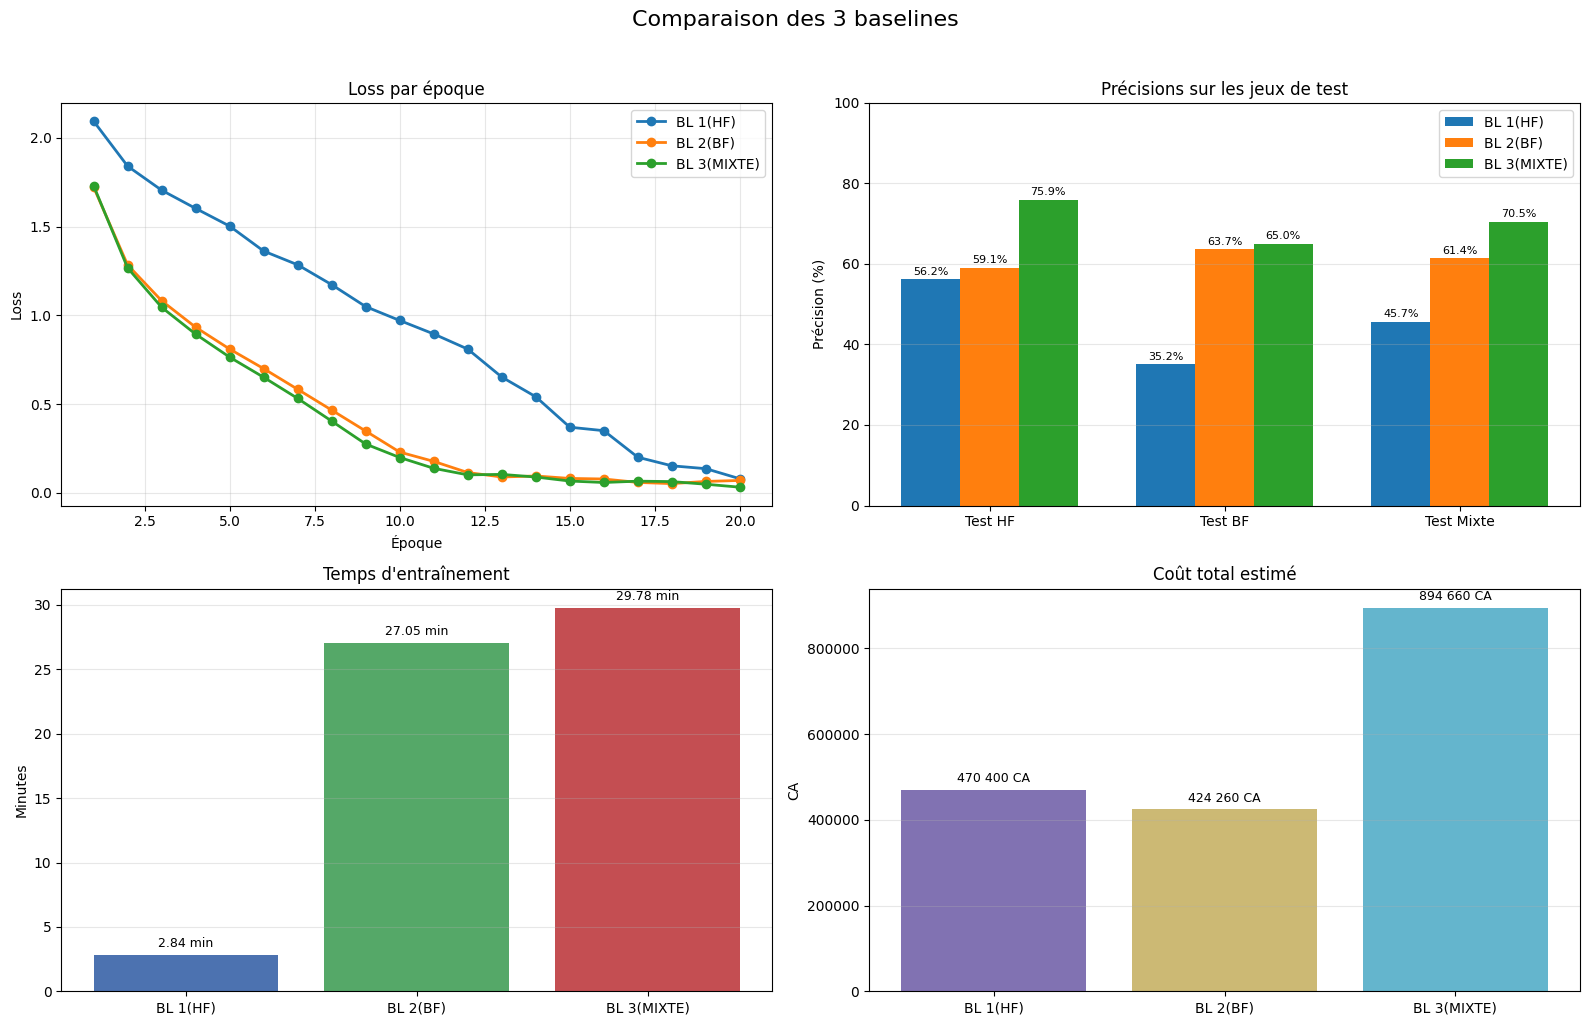

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Données récupérées depuis la sortie d'entraînement (cellule 6)
baseline_keys = ["HF", "BF", "MIXTE"]
baseline_labels = {
    "HF": "BL 1(HF)",
    "BF": "BL 2(BF)",
    "MIXTE": "BL 3(MIXTE)",
}
epochs = np.arange(1, 21)

losses = {
    "HF": [2.0949, 1.8412, 1.7056, 1.6029, 1.5031, 1.3624, 1.2850, 1.1730, 1.0493, 0.9712, 0.8952, 0.8098, 0.6523, 0.5412, 0.3695, 0.3500, 0.2002, 0.1520, 0.1358, 0.0789],
    "BF": [1.7230, 1.2843, 1.0825, 0.9331, 0.8101, 0.6997, 0.5832, 0.4659, 0.3478, 0.2293, 0.1769, 0.1139, 0.0890, 0.0946, 0.0808, 0.0776, 0.0583, 0.0517, 0.0639, 0.0695],
    "MIXTE": [1.7312, 1.2675, 1.0455, 0.8942, 0.7644, 0.6509, 0.5318, 0.4039, 0.2746, 0.1987, 0.1378, 0.1010, 0.1036, 0.0887, 0.0661, 0.0579, 0.0654, 0.0630, 0.0481, 0.0314],
}

acc_labels = ["Test HF", "Test BF", "Test Mixte"]
accuracies = {
    "HF": [56.20, 35.16, 45.68],
    "BF": [59.07, 63.66, 61.36],
    "MIXTE": [75.90, 65.03, 70.47],
}

train_time_min = {
    "HF": 2.84,
    "BF": 27.05,
    "MIXTE": 29.78,
}

cost_total_ca = {
    "HF": 470400,
    "BF": 424260,
    "MIXTE": 894660,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparaison des 3 baselines", fontsize=16, y=1.02)

# 1) Courbes de loss
ax = axes[0, 0]
for k in baseline_keys:
    ax.plot(epochs, losses[k], marker="o", linewidth=2, label=baseline_labels[k])
ax.set_title("Loss par \u00e9poque")
ax.set_xlabel("\u00c9poque")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()

# 2) Précisions test (barres groupées)
ax = axes[0, 1]
x = np.arange(len(acc_labels))
width = 0.25
for i, k in enumerate(baseline_keys):
    vals = accuracies[k]
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=baseline_labels[k])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.6, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Pr\u00e9cisions sur les jeux de test")
ax.set_xticks(x)
ax.set_xticklabels(acc_labels)
ax.set_ylabel("Pr\u00e9cision (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend()

# 3) Temps d'entraînement total
ax = axes[1, 0]
time_vals = [train_time_min[k] for k in baseline_keys]
bars = ax.bar([baseline_labels[k] for k in baseline_keys], time_vals, color=["#4C72B0", "#55A868", "#C44E52"])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.2f} min", ha="center", va="bottom", fontsize=9)
ax.set_title("Temps d'entra\u00eenement")
ax.set_ylabel("Minutes")
ax.grid(axis="y", alpha=0.3)

# 4) Coût total estimé
ax = axes[1, 1]
cost_vals = [cost_total_ca[k] for k in baseline_keys]
bars = ax.bar([baseline_labels[k] for k in baseline_keys], cost_vals, color=["#8172B2", "#CCB974", "#64B5CD"])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 10000, f"{int(h):,} CA".replace(",", " "), ha="center", va="bottom", fontsize=9)
ax.set_title("Co\u00fbt total estim\u00e9")
ax.set_ylabel("CA")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()